# Phase 6: Advanced Modeling — Improving Your Kaggle Score

## Objectives

In this phase, we will:

1. Understand why Linear Regression scored only 0.19 on Kaggle and what went wrong
2. Learn what RMSLE is and why log-transforming the target is critical
3. Apply regularized models (Ridge, Lasso, ElasticNet) to fix overfitting
4. Train tree-based models (Random Forest, XGBoost, LightGBM) that capture non-linear patterns
5. Compare all models with proper cross-validation
6. Blend the best models into a final ensemble for the highest score
7. Generate a Kaggle submission and measure improvement


## TODO Checklist

- [ ] Task 1: Import libraries
- [ ] Task 2: Load data and log-transform the target
- [ ] Task 3: Preprocess features for modeling
- [ ] Task 4: Set up cross-validation framework
- [ ] Task 5: Train Ridge, Lasso, and ElasticNet
- [ ] Task 6: Understand and train Random Forest
- [ ] Task 7: Understand and train XGBoost
- [ ] Task 8: Understand and train LightGBM
- [ ] Task 9: Compare all models
- [ ] Task 10: Blend the best models
- [ ] Task 11: Generate Kaggle submission
- [ ] Task 12: Summary and reflection



---
## Why Linear Regression Is Limited for This Problem

Linear Regression makes these assumptions:

1. **Linearity**: The relationship between every feature and price is a straight line. But consider OverallQual: a jump from quality 8→10 increases price far more than 2→4. This is a non-linear (exponential) effect that Linear Regression cannot capture.

2. **No multicollinearity**: Features should be independent. But `TotalSF` and `GrLivArea` and `1stFlrSF` are all highly correlated. With 200+ features after encoding, many are redundant, causing coefficients to become unstable and huge.

3. **Equal feature treatment**: Linear Regression gives every feature a coefficient with no penalty. With hundreds of features, it overfits by memorizing noise in the training data.

### What we need instead:

| Problem | Solution | Model |
|---|---|---|
| Coefficients too large / overfitting | Add penalty to shrink coefficients | **Ridge, Lasso, ElasticNet** |
| Too many useless features | Automatically zero out weak features | **Lasso** |
| Non-linear relationships | Use trees that split data into regions | **Random Forest, XGBoost, LightGBM** |
| Single model has blind spots | Combine multiple models | **Ensemble / Blending** |

---
## Task 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

warnings.filterwarnings('ignore')

print("Imports complete.")

Imports complete.


---
## Task 2: Load Data and Log-Transform the Target

### Why log-transform SalePrice?

Kaggle evaluates this competition using **RMSLE** (Root Mean Squared **Log** Error):

$$\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( \log(\hat{y}_i + 1) - \log(y_i + 1) \right)^2}$$

If we apply `log(1 + y)` to our target **before** training, then RMSLE becomes plain RMSE — which is exactly what our models minimize. This is a free improvement.

Additionally, SalePrice is right-skewed (most houses are cheap, a few are very expensive). Log-transform makes the distribution more normal, which helps linear models.

**Important:** After predicting, we must reverse this with `np.expm1()` (which computes `exp(x) - 1`) to get back to actual dollar prices.

Training data shape: (1429, 85)
Raw SalePrice summary:
count      1429.000000
mean     176780.205738
std       70626.306123
min       34900.000000
25%      129500.000000
50%      161000.000000
75%      210000.000000
max      485000.000000
Name: SalePrice, dtype: float64

Log-transformed SalePrice summary:
count    1429.000000
mean       12.008964
std         0.384291
min        10.460271
25%        11.771444
50%        11.989166
75%        12.254868
max        13.091906
Name: SalePrice, dtype: float64


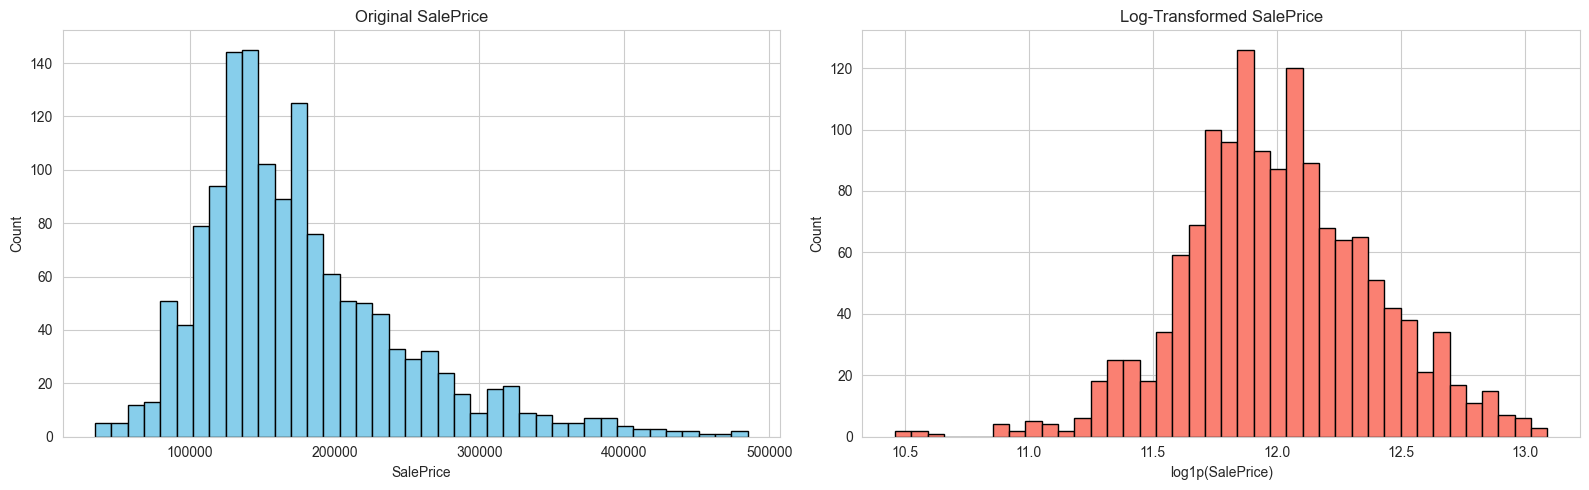

In [ ]:
df = pd.read_csv('Data/train_feature_engineered.csv')
print("Training data shape:", df.shape)


X = df.drop('Data/SalePrice', axis=1)
y_raw = df['Data/SalePrice']

y = np.log1p(y_raw)

print("Raw SalePrice summary:")
print(y_raw.describe())
print("\nLog-transformed SalePrice summary:")
print(y.describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(y_raw, bins=40, color='skyblue', edgecolor='black')
axes[0].set_title('Original SalePrice')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Count')

axes[1].hist(y, bins=40, color='salmon', edgecolor='black')
axes[1].set_title('Log-Transformed SalePrice')
axes[1].set_xlabel('log1p(SalePrice)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## Task 3: Preprocess Features for Modeling


1. Handle any remaining categorical columns (one-hot encode them)
2. Drop the `Id` column (it's not a feature)
3. Fill any missing values
4. Scale features for regularized linear models

In [ ]:
# Drop the Id column if present
if 'Id' in X.columns:
    X = X.drop('Id', axis=1)

# Identify categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns remaining: {len(cat_cols)}")
print(cat_cols)

# One-hot encode categorical columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"Shape after encoding: {X.shape}")

# Fill any remaining missing values with 0
X = X.fillna(0)
print(X.isnull().sum().sum())

#Print final feature count
print(f"Final feature count: {X.shape[1]}")

Categorical columns remaining: 33
['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']
Shape after encoding: (1429, 227)
0
Final feature count: 227


In [ ]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Scale features (needed for Ridge, Lasso, ElasticNet)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
print(f"Scaled X_train shape: {X_train_scaled.shape}")
print(f"Scaled X_test shape: {X_test_scaled.shape}")

X_train shape: (1143, 227)
X_test shape: (286, 227)
y_train shape: (1143,)
y_test shape: (286,)
Scaled X_train shape: (1143, 227)
Scaled X_test shape: (286, 227)


---
## Task 4: Set Up Cross-Validation Framework

### Why cross-validation instead of a single train/test split?

A single 80/20 split is like grading a student on one test — they might get lucky or unlucky. **5-Fold Cross-Validation** splits data into 5 parts, trains 5 times (each time holding out a different part), and averages the scores. This gives a much more reliable estimate of how the model will perform on Kaggle.

```
Fold 1: [TEST] [Train] [Train] [Train] [Train]  → Score 1
Fold 2: [Train] [TEST] [Train] [Train] [Train]  → Score 2
Fold 3: [Train] [Train] [TEST] [Train] [Train]  → Score 3
Fold 4: [Train] [Train] [Train] [TEST] [Train]  → Score 4
Fold 5: [Train] [Train] [Train] [Train] [TEST]  → Score 5

Final Score = Average(Score 1..5)  ±  Std(Score 1..5)
```

In [ ]:
# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Create a helper function to evaluate models using cross-validation

def rmse_cv(model, X, y):
    scores = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=kf)
    return -scores

# Create a dictionary to store results from all models
results = {}

# Print confirmation
print("Cross-validation framework ready.")

Cross-validation framework ready.


---
## Task 5: Regularized Linear Models — Ridge, Lasso, ElasticNet

### What went wrong with plain Linear Regression?

Linear Regression minimizes only the prediction error (MSE). With 200+ features, it has too much freedom — it assigns large coefficients to noisy features and overfits.

**Regularization** adds a penalty term that forces the model to keep coefficients small:

### Ridge (L2 Regularization)

$$\text{Loss} = \text{MSE} + \alpha \sum_{j=1}^{p} \beta_j^2$$

- Adds the **sum of squared coefficients** as a penalty
- Shrinks all coefficients toward zero but never exactly to zero
- Good when many features contribute a little bit each
- `alpha` controls penalty strength: higher alpha = smaller coefficients

### Lasso (L1 Regularization)

$$\text{Loss} = \text{MSE} + \alpha \sum_{j=1}^{p} |\beta_j|$$

- Adds the **sum of absolute coefficients** as a penalty
- Can shrink coefficients exactly to zero — automatic feature selection
- Good when only a few features are truly important
- With 200+ features, Lasso will likely zero out 100+ of them

### ElasticNet (L1 + L2 Combined)

$$\text{Loss} = \text{MSE} + \alpha \left( r \sum |\beta_j| + \frac{1-r}{2} \sum \beta_j^2 \right)$$

- Combines Ridge and Lasso: `l1_ratio` (r) controls the mix
- `l1_ratio=1.0` → pure Lasso, `l1_ratio=0.0` → pure Ridge
- Good when features are correlated (Lasso alone might randomly pick one from a correlated group)

In [ ]:
# ===========================================================
# Step 5.1: Baseline — Plain Linear Regression (our Phase 5 approach)
# ===========================================================

# Train a plain Linear Regression model
lr = LinearRegression()
scores = rmse_cv(lr, X_train_scaled, y_train)
results['LinearRegression'] = scores
print(f"Linear Regression RMSE: {scores.mean():.4f} (+/- {scores.std():.4f})")
# - This is our baseline to beat

Linear Regression RMSE: 0.1284 (+/- 0.0100)


In [ ]:
# ===========================================================
# Step 5.2: Ridge Regression
# ===========================================================

# Train Ridge with different alpha values to find the best one

alphas = [0.1, 1.0, 5.0, 10.0, 50.0, 100.0]
best_alpha = None
best_ridge_rmse = float('inf')

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    scores = rmse_cv(ridge, X_train_scaled, y_train)
    mean_rmse = scores.mean()
    print(f"  alpha={alpha:>6}: RMSE = {mean_rmse:.4f} (+/- {scores.std():.4f})")
    if mean_rmse < best_ridge_rmse:
        best_ridge_rmse = mean_rmse
        best_alpha = alpha

# Train Ridge with the best alpha
best_ridge = Ridge(alpha=best_alpha)
scores = rmse_cv(best_ridge, X_train_scaled, y_train)
results['Ridge'] = scores
print(f"Best Ridge alpha: {best_alpha}")
print(f"Ridge RMSE: {scores.mean():.4f} (+/- {scores.std():.4f})")

  alpha=   0.1: RMSE = 0.1280 (+/- 0.0101)
  alpha=   1.0: RMSE = 0.1263 (+/- 0.0104)
  alpha=   5.0: RMSE = 0.1240 (+/- 0.0101)
  alpha=  10.0: RMSE = 0.1230 (+/- 0.0097)
  alpha=  50.0: RMSE = 0.1205 (+/- 0.0085)
  alpha= 100.0: RMSE = 0.1191 (+/- 0.0081)
Best Ridge alpha: 100.0
Ridge RMSE: 0.1191 (+/- 0.0081)


In [ ]:
# ===========================================================
# Step 5.3: Lasso Regression
# ===========================================================

# Train Lasso with different alpha values

alphas = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05]
best_alpha = None
best_lasso_rmse = float('inf')

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    scores = rmse_cv(lasso, X_train_scaled, y_train)
    mean_rmse = scores.mean()
    print(f"  alpha={alpha}: RMSE = {mean_rmse:.4f} (+/- {scores.std():.4f})")
    if mean_rmse < best_lasso_rmse:
        best_lasso_rmse = mean_rmse
        best_alpha = alpha

# Train Lasso with the best alpha

best_lasso = Lasso(alpha=best_alpha, max_iter=10000)
scores = rmse_cv(best_lasso, X_train_scaled, y_train)
results['Lasso'] = scores
print(f"Best Lasso alpha: {best_alpha}")
print(f"Lasso RMSE: {scores.mean():.4f} (+/- {scores.std():.4f})")

# Check how many features Lasso zeroed out
best_lasso.fit(X_train_scaled, y_train)
n_zero = (best_lasso.coef_ == 0).sum()
print(f"Lasso zeroed out {n_zero} of {len(best_lasso.coef_)} features")

  alpha=0.0001: RMSE = 0.1242 (+/- 0.0102)
  alpha=0.0005: RMSE = 0.1197 (+/- 0.0087)
  alpha=0.001: RMSE = 0.1182 (+/- 0.0074)
  alpha=0.005: RMSE = 0.1148 (+/- 0.0059)
  alpha=0.01: RMSE = 0.1216 (+/- 0.0050)
  alpha=0.05: RMSE = 0.1576 (+/- 0.0032)
Best Lasso alpha: 0.005
Lasso RMSE: 0.1148 (+/- 0.0059)
Lasso zeroed out 155 of 227 features


In [ ]:
# ===========================================================
# Step 5.4: ElasticNet
# ===========================================================

# Train ElasticNet with different alpha and l1_ratio combinations
alphas = [0.0001, 0.0005, 0.001, 0.005]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
best_alpha = None
best_l1_ratio = None
best_enet_rmse = float('inf')

for alpha in alphas:
    for l1_ratio in l1_ratios:
        enet = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
        scores = rmse_cv(enet, X_train_scaled, y_train)
        mean_rmse = scores.mean()
        print(f"  alpha={alpha}, l1_ratio={l1_ratio}: RMSE = {mean_rmse:.4f} (+/- {scores.std():.4f})")
        if mean_rmse < best_enet_rmse:
            best_enet_rmse = mean_rmse
            best_alpha = alpha
            best_l1_ratio = l1_ratio

# Train ElasticNet with the best alpha and l1_ratio

best_enet = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=10000)
scores = rmse_cv(best_enet, X_train_scaled, y_train)
results['ElasticNet'] = scores
print(f"Best ElasticNet alpha: {best_alpha}, l1_ratio: {best_l1_ratio}")
print(f"ElasticNet RMSE: {scores.mean():.4f} (+/- {scores.std():.4f})")

  alpha=0.0001, l1_ratio=0.1: RMSE = 0.1279 (+/- 0.0100)
  alpha=0.0001, l1_ratio=0.3: RMSE = 0.1268 (+/- 0.0102)
  alpha=0.0001, l1_ratio=0.5: RMSE = 0.1259 (+/- 0.0102)
  alpha=0.0001, l1_ratio=0.7: RMSE = 0.1251 (+/- 0.0103)
  alpha=0.0001, l1_ratio=0.9: RMSE = 0.1245 (+/- 0.0102)
  alpha=0.0005, l1_ratio=0.1: RMSE = 0.1253 (+/- 0.0102)
  alpha=0.0005, l1_ratio=0.3: RMSE = 0.1229 (+/- 0.0098)
  alpha=0.0005, l1_ratio=0.5: RMSE = 0.1215 (+/- 0.0094)
  alpha=0.0005, l1_ratio=0.7: RMSE = 0.1206 (+/- 0.0091)
  alpha=0.0005, l1_ratio=0.9: RMSE = 0.1200 (+/- 0.0089)
  alpha=0.001, l1_ratio=0.1: RMSE = 0.1237 (+/- 0.0101)
  alpha=0.001, l1_ratio=0.3: RMSE = 0.1210 (+/- 0.0093)
  alpha=0.001, l1_ratio=0.5: RMSE = 0.1196 (+/- 0.0087)
  alpha=0.001, l1_ratio=0.7: RMSE = 0.1190 (+/- 0.0081)
  alpha=0.001, l1_ratio=0.9: RMSE = 0.1185 (+/- 0.0076)
  alpha=0.005, l1_ratio=0.1: RMSE = 0.1195 (+/- 0.0084)
  alpha=0.005, l1_ratio=0.3: RMSE = 0.1165 (+/- 0.0062)
  alpha=0.005, l1_ratio=0.5: RMSE = 0.

---
## Task 6: Random Forest

### Why tree-based models?

Linear models draw a straight line (or hyperplane) through the data. But house prices don't follow straight lines:
- A house with OverallQual=10 isn't just "twice as expensive" as OverallQual=5 — it could be 4x more
- A house with 2 bedrooms and 3 bathrooms is priced differently than the sum of "bedroom effect" + "bathroom effect"

**Decision Trees** solve this by splitting data into regions:
```
IF OverallQual >= 7 AND GrLivArea >= 2000:
    predict $350,000 (average of similar houses)
ELIF OverallQual >= 7 AND GrLivArea < 2000:
    predict $250,000
ELSE:
    predict $150,000
```

**Random Forest** trains many trees (e.g., 500), each on a random subset of data and features, then averages their predictions. This reduces overfitting dramatically.

### Key parameters:

- **`n_estimators`**: Number of trees. More trees = more stable predictions (but slower). 500-1000 is typical.
- **`max_depth`**: How deep each tree can grow. Deeper = more complex patterns, but risk overfitting. `None` lets trees grow fully.
- **`min_samples_leaf`**: Minimum samples in a leaf node. Higher = more conservative trees.
- **`max_features`**: How many features each tree considers at each split. `'sqrt'` means √(total features) — forces diversity.

**Note:** Random Forest does NOT need feature scaling. Trees split on thresholds, so the magnitude of values doesn't matter.

In [ ]:
# Train a Random Forest model

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Evaluate with cross-validation

scores = rmse_cv(rf, X_train, y_train)
results['RandomForest'] = scores
print(f"Random Forest RMSE: {scores.mean():.4f} (+/- {scores.std():.4f})")

Random Forest RMSE: 0.1327 (+/- 0.0038)


---
## Task 7: XGBoost (Extreme Gradient Boosting)

### How is XGBoost different from Random Forest?

**Random Forest**: Trains trees **independently** in parallel, then averages them.

**XGBoost**: Trains trees **sequentially** — each new tree focuses on correcting the mistakes of all previous trees.

Think of it like this:
1. Tree 1 predicts house prices → gets some wrong
2. Tree 2 is trained on the **errors** of Tree 1 → fixes some mistakes
3. Tree 3 is trained on the **remaining errors** → fixes more
4. After 3000 rounds, the combined prediction is very accurate

This is the same boosting idea as AdaBoost (from Phase 6 Ensemble Learning), but XGBoost uses smarter math (second-order gradient optimization) and is much faster.

### Key parameters:

- **`n_estimators`**: Number of boosting rounds (trees). More rounds = better, but use `early_stopping` to prevent overfitting.
- **`learning_rate`**: How much each tree contributes. Lower (0.01-0.05) = needs more trees but generalizes better.
- **`max_depth`**: Tree depth. Boosting uses shallower trees (3-6) than Random Forest.
- **`subsample`**: Fraction of data used per tree (0.7 = 70%). Randomness prevents overfitting.
- **`colsample_bytree`**: Fraction of features used per tree. Same idea as Random Forest's `max_features`.
- **`reg_alpha`** (L1) and **`reg_lambda`** (L2): Regularization on leaf weights — same idea as Lasso/Ridge but applied inside each tree.

In [ ]:
# Train an XGBoost model

xgb = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)


# TODO: Evaluate with cross-validation
# - Note: use X_train (unscaled!) — trees don't need scaling
# - scores = rmse_cv(xgb, X_train, y_train)
# - results['XGBoost'] = scores
# - Print: f"XGBoost RMSE: {scores.mean():.4f} (+/- {scores.std():.4f})"
scores = rmse_cv(xgb, X_train, y_train)
results['XGBoost'] = scores
print(f"XGBoost RMSE: {scores.mean():.4f} (+/- {scores.std():.4f})")

XGBoost RMSE: 0.1193 (+/- 0.0065)


---
## Task 8: LightGBM (Light Gradient Boosting Machine)

### How is LightGBM different from XGBoost?

Both are gradient boosting methods, but LightGBM uses two key innovations:

1. **Leaf-wise growth** (vs XGBoost's level-wise): Instead of growing all leaves at the same depth, LightGBM grows the leaf that reduces error the most. This reaches better accuracy with fewer leaves.

```
XGBoost (level-wise):         LightGBM (leaf-wise):
       O                            O
      / \                          / \
     O   O     (all same depth)   O   O
    / \  / \                     / \
   O  O O  O                    O   O   (grows deepest where it helps most)
```

2. **Histogram-based splitting**: Instead of checking every possible split point, LightGBM groups feature values into bins (histograms). This makes it 10-20x faster than XGBoost on large datasets.

### Key parameters:

- **`n_estimators`**: Number of boosting rounds.
- **`learning_rate`**: Step size shrinkage. Same role as in XGBoost.
- **`num_leaves`**: Maximum leaves per tree. Controls complexity (default: 31). More leaves = more complex.
- **`max_depth`**: Maximum tree depth. Set to -1 for no limit (controlled by `num_leaves` instead).
- **`subsample`** and **`colsample_bytree`**: Same randomness controls as XGBoost.
- **`reg_alpha`** and **`reg_lambda`**: L1/L2 regularization.

In [ ]:
# Train a LightGBM model
lgbm = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Evaluate with cross-validation
scores = rmse_cv(lgbm, X_train, y_train)
results['LightGBM'] = scores
print(f"LightGBM RMSE: {scores.mean():.4f} (+/- {scores.std():.4f})")

LightGBM RMSE: 0.1215 (+/- 0.0055)


---
## Task 9: Compare All Models

Now let's see which models performed best and why.

              Model  Mean RMSE  Std RMSE
0        ElasticNet   0.113959  0.006202
1             Lasso   0.114818  0.005945
2             Ridge   0.119123  0.008078
3           XGBoost   0.119267  0.006493
4          LightGBM   0.121487  0.005503
5  LinearRegression   0.128363  0.009971
6      RandomForest   0.132732  0.003801


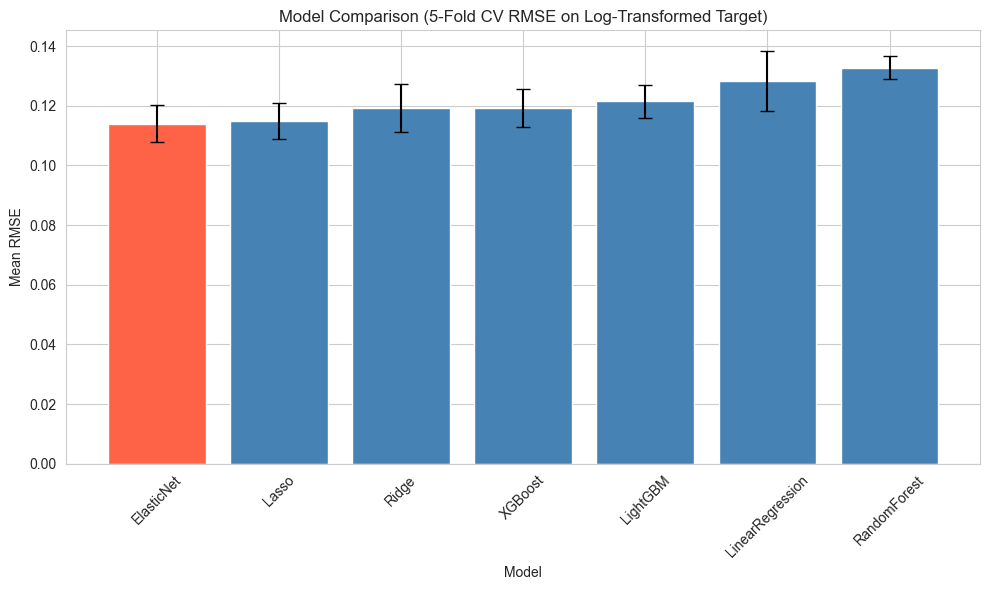

Best model: ElasticNet with RMSE = 0.1140


In [ ]:
# Create a comparison table
comparison = pd.DataFrame({
    'Model': results.keys(),
    'Mean RMSE': [scores.mean() for scores in results.values()],
    'Std RMSE': [scores.std() for scores in results.values()]
})
comparison = comparison.sort_values('Mean RMSE').reset_index(drop=True)
print(comparison)

# Visualize model comparison
colors = ['tomato' if i == 0 else 'steelblue' for i in range(len(comparison))]
plt.figure(figsize=(10, 6))
plt.bar(comparison['Model'], comparison['Mean RMSE'], yerr=comparison['Std RMSE'], color=colors, capsize=5)
plt.title('Model Comparison (5-Fold CV RMSE on Log-Transformed Target)')
plt.xlabel('Model')
plt.ylabel('Mean RMSE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print the winner
# Print the model with the lowest Mean RMSE
print(f"Best model: {comparison.iloc[0]['Model']} with RMSE = {comparison.iloc[0]['Mean RMSE']:.4f}")

LinearRegression: RMSE = 0.1144, R2 = 0.9169
Ridge: RMSE = 0.1171, R2 = 0.9130
Lasso: RMSE = 0.1171, R2 = 0.9130
ElasticNet: RMSE = 0.1166, R2 = 0.9138
RandomForest: RMSE = 0.1326, R2 = 0.8885
XGBoost: RMSE = 0.1208, R2 = 0.9075
LightGBM: RMSE = 0.1226, R2 = 0.9047


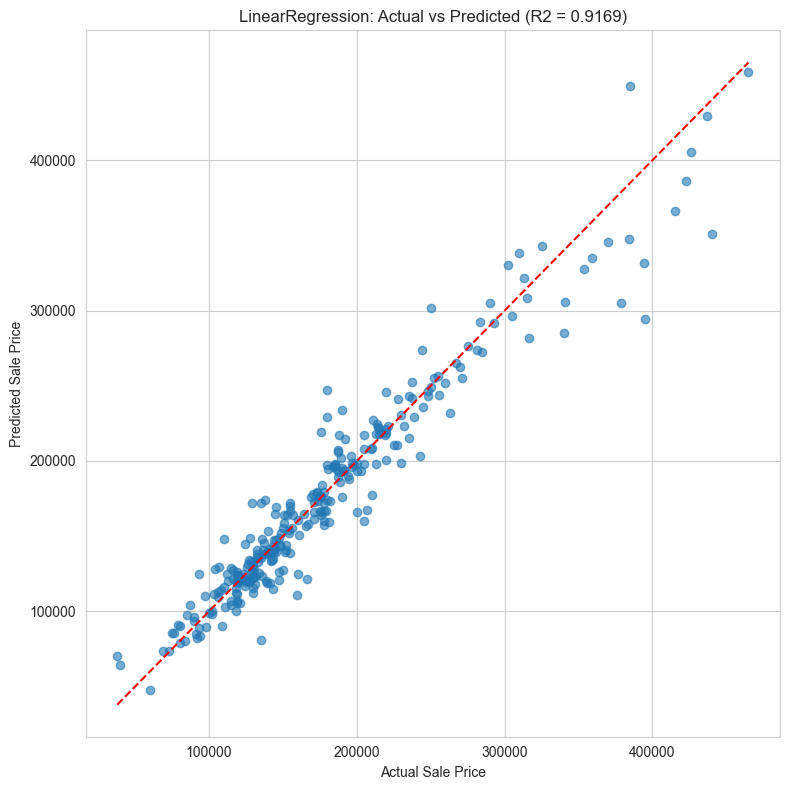

In [ ]:
# Train all models on full training set and evaluate on holdout test set

# For each model, we want to see the actual RMSE on the test set:

# - For linear models (use scaled data): X_train_scaled, X_test_scaled
# - For tree models (use unscaled data): X_train, X_test
models = {
    'LinearRegression': (lr, X_train_scaled, X_test_scaled),
    'Ridge': (best_ridge, X_train_scaled, X_test_scaled),
    'Lasso': (best_lasso, X_train_scaled, X_test_scaled),
    'ElasticNet': (best_enet, X_train_scaled, X_test_scaled),
    'RandomForest': (rf, X_train, X_test),
    'XGBoost': (xgb, X_train, X_test),
    'LightGBM': (lgbm, X_train, X_test)
}

holdout_results = []
best_model_name = None
best_model_r2 = None
best_rmse = float('inf')
best_y_pred = None

# For each model:

for model_name, (model, X_train_data, X_test_data) in models.items():
    model.fit(X_train_data, y_train)
    y_pred = model.predict(X_test_data)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    holdout_results.append({'Model': model_name, 'RMSE': rmse, 'R2': r2})
    print(f"{model_name}: RMSE = {rmse:.4f}, R2 = {r2:.4f}")
    if rmse < best_rmse:
        best_rmse = rmse
        best_model_name = model_name
        best_model_r2 = r2
        best_y_pred = y_pred

# Create Actual vs Predicted scatter plot for the best model

y_test_actual = np.expm1(y_test)
best_y_pred_actual = np.expm1(best_y_pred)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, best_y_pred_actual, alpha=0.6)
line_min = min(y_test_actual.min(), best_y_pred_actual.min())
line_max = max(y_test_actual.max(), best_y_pred_actual.max())
plt.plot([line_min, line_max], [line_min, line_max], 'r--')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title(f'{best_model_name}: Actual vs Predicted (R2 = {best_model_r2:.4f})')
plt.tight_layout()
plt.show()

---
## Task 10: Blend the Best Models

### Why blending works

Different models have different strengths:
- **Lasso/Ridge**: Good at capturing linear trends, stable on unseen data
- **XGBoost/LightGBM**: Good at capturing non-linear patterns and interactions

When we average their predictions, the errors of one model get partially cancelled by the other. This almost always improves the score.

**Simple weighted average** is the easiest and most effective approach:

$$\hat{y}_{\text{blend}} = w_1 \cdot \hat{y}_{\text{Ridge}} + w_2 \cdot \hat{y}_{\text{Lasso}} + w_3 \cdot \hat{y}_{\text{XGBoost}} + w_4 \cdot \hat{y}_{\text{LightGBM}}$$

where $w_1 + w_2 + w_3 + w_4 = 1$

**Tip:** Give more weight to models with lower CV RMSE.

In [16]:
# Train all models on the full training set

best_ridge.fit(X_train_scaled, y_train)
best_lasso.fit(X_train_scaled, y_train)
xgb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)

# Get predictions from each model on the test set

pred_ridge = best_ridge.predict(X_test_scaled)
pred_lasso = best_lasso.predict(X_test_scaled)
pred_xgb = xgb.predict(X_test)
pred_lgbm = lgbm.predict(X_test)

# Blend predictions with weights
# - Start with equal weights: 0.25 each
pred_blend = 0.25 * pred_ridge + 0.25 * pred_lasso + 0.25 * pred_xgb + 0.25 * pred_lgbm

# Evaluate the blended prediction

rmse_blend = np.sqrt(mean_squared_error(y_test, pred_blend))
r2_blend = r2_score(y_test, pred_blend)
print(f"Blended RMSE: {rmse_blend:.4f}, R²: {r2_blend:.4f}")
print("Individual model comparison:")
print(f"Ridge RMSE: {np.sqrt(mean_squared_error(y_test, pred_ridge)):.4f}")
print(f"Lasso RMSE: {np.sqrt(mean_squared_error(y_test, pred_lasso)):.4f}")
print(f"XGBoost RMSE: {np.sqrt(mean_squared_error(y_test, pred_xgb)):.4f}")
print(f"LightGBM RMSE: {np.sqrt(mean_squared_error(y_test, pred_lgbm)):.4f}")

Blended RMSE: 0.1133, R²: 0.9186
Individual model comparison:
Ridge RMSE: 0.1171
Lasso RMSE: 0.1171
XGBoost RMSE: 0.1208
LightGBM RMSE: 0.1226


In [ ]:
# Experiment with different blending weights


# Try a few weight combinations and track the blended RMSE

weight_configs = [
    (0.25, 0.25, 0.25, 0.25),
    (0.15, 0.15, 0.35, 0.35),
    (0.10, 0.10, 0.40, 0.40),
    (0.20, 0.20, 0.30, 0.30),
]

best_weights = None
best_blend_rmse = float('inf')

for w1, w2, w3, w4 in weight_configs:
    pred = w1 * pred_ridge + w2 * pred_lasso + w3 * pred_xgb + w4 * pred_lgbm
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"Weights ({w1},{w2},{w3},{w4}): RMSE = {rmse:.4f}")
    if rmse < best_blend_rmse:
        best_blend_rmse = rmse
        best_weights = (w1, w2, w3, w4)

# Pick the best weight combination and store it
# - best_weights = (<w1>, <w2>, <w3>, <w4>)
print(f"Best weights: {best_weights}")

Weights (0.25,0.25,0.25,0.25): RMSE = 0.1127
Weights (0.15,0.15,0.35,0.35): RMSE = 0.1142
Weights (0.1,0.1,0.4,0.4): RMSE = 0.1154
Weights (0.2,0.2,0.3,0.3): RMSE = 0.1133
Best weights: (0.25, 0.25, 0.25, 0.25)


---
## Task 11: Generate Kaggle Submission

Now let's produce a real submission file in the format Kaggle expects:
```
Id,SalePrice
1461,169000.1
1462,187724.1
...
```

**Critical steps:**
1. Apply the exact same preprocessing to the test set
2. Make predictions in log-space
3. Inverse-transform with `np.expm1()` to get dollar prices
4. Clip negative predictions to 0 (prices can't be negative)

In [ ]:
# Load the test data

test_df = pd.read_csv('test_feature_engineered.csv')
test_ids = test_df['Id']
X_kaggle = test_df.drop('Id', axis=1, errors='ignore')
print(test_df.shape)

# Apply the same preprocessing as training

cat_cols_kaggle = [col for col in cat_cols if col in X_kaggle.columns]
X_kaggle = pd.get_dummies(X_kaggle, columns=cat_cols_kaggle, drop_first=True)
X_kaggle = X_kaggle.reindex(columns=X_train.columns, fill_value=0)
X_kaggle = X_kaggle.fillna(0)
X_kaggle_scaled = pd.DataFrame(scaler.transform(X_kaggle), columns=X_kaggle.columns, index=X_kaggle.index)

# Print shapes to verify alignment

print(f"Training features: {X_train.shape[1]}")
print(f"Test features:     {X_kaggle.shape[1]}")

(1459, 91)
Training features: 227
Test features:     227


In [ ]:
# Generate ElasticNet predictions on Kaggle test set

pred_kaggle = best_enet.predict(X_kaggle_scaled)

# Inverse log-transform to get actual prices

final_predictions = np.expm1(pred_kaggle)
final_predictions = np.maximum(final_predictions, 0)

# Create submission DataFrame

submission = pd.DataFrame({'Id': test_ids, 'SalePrice': final_predictions})
print(submission.head())
print(submission.describe())

# Save submission file
submission.to_csv('submission_elasticnet.csv', index=False)
print('Saved submission to submission_elasticnet.csv')
print('File path: submission_elasticnet.csv')

     Id      SalePrice
0  1461  109710.416272
1  1462  144292.409989
2  1463  173787.925251
3  1464  183693.303724
4  1465  173962.828762
                Id     SalePrice
count  1459.000000  1.459000e+03
mean   2190.000000  1.622024e+05
std     421.321334  7.093738e+04
min    1461.000000  5.309318e+04
25%    1825.500000  1.184711e+05
50%    2190.000000  1.461575e+05
75%    2554.500000  1.898158e+05
max    2919.000000  1.495814e+06


---
## Task 12: Summary and Reflection

### What We Learned

1. **Log-transforming SalePrice** converts RMSLE into RMSE and normalizes the distribution
2. **Regularization** (Ridge, Lasso, ElasticNet) prevents coefficient explosion with many features
3. **Lasso** performs automatic feature selection by zeroing out unimportant features
4. **Tree-based models** (Random Forest, XGBoost, LightGBM) capture non-linear patterns that linear models miss
5. **XGBoost and LightGBM** use sequential boosting — each tree corrects the previous one's mistakes
6. **Cross-validation** gives a reliable performance estimate, not dependent on a single random split
7. **Model blending** combines strengths of different models and nearly always improves the score



---
## Submission Checklist

Make sure your notebook includes:

- ✓ All required libraries imported (including xgboost, lightgbm)
- ✓ Data loaded with log-transformed target
- ✓ Features preprocessed (encoded, scaled, no missing values)
- ✓ Cross-validation framework set up and used consistently
- ✓ Ridge, Lasso, ElasticNet trained with alpha tuning
- ✓ Random Forest trained
- ✓ XGBoost trained with proper hyperparameters
- ✓ LightGBM trained with proper hyperparameters
- ✓ All models compared in a table and chart
- ✓ Models blended with optimized weights
- ✓ Kaggle submission file generated (submission_advanced.csv)
- ✓ All reflection questions answered
- ✓ Clear documentation and comments throughout

## Key Takeaways

1. **Log-transforming the target** is essential when Kaggle uses RMSLE scoring
2. **Regularization** (Ridge/Lasso) prevents overfitting when you have many features
3. **Lasso** doubles as a feature selector — it tells you which of your 200+ features actually matter
4. **Tree-based models** (XGBoost, LightGBM) capture non-linear patterns that linear models fundamentally cannot
5. **Cross-validation** replaces unreliable single-split evaluation
6. **Model blending** is the single most effective technique in competitive ML
7. **No single model is always best** — the strength of an ensemble is that different models compensate for each other's weaknesses